In [7]:
import sys
import importlib
sys.path.append('../../')  # Adjust the path as needed

import utilities.functions as functions
import utilities.plot as plot

# Reload the module to reflect the changes
importlib.reload(functions)
importlib.reload(plot)

IN_seq_path = '../IN/data/in.reduce4.seq'
PR_seq_path = '../PR/data/pr.exper.reduce4.seq'    
RT_seq_path = '../RT/data/rt.reduce4.seq'

IN_all_seq = functions.read_seq(IN_seq_path)
PR_all_seq = functions.read_seq(PR_seq_path)
RT_all_seq = functions.read_seq(RT_seq_path)

IN_consensus = '../IN/data/in.consensus.reduce4.seq'
with open(IN_consensus, 'r') as f:
    IN_consensus_seq = f.read().strip()
# print("IN consensus sequence:", IN_consensus_seq)
PR_consensus = '../PR/data/pr.consensus.reduce4.seq'
with open(PR_consensus, 'r') as f:
    PR_consensus_seq = f.read().strip()
# PR_consensus_seq_unreduced = functions.get_unreduced_consensus(PR_consensus_seq, PR_J, 1, 99)
RT_consensus = '../RT/data/rt.consensus.reduce4.seq'
with open(RT_consensus, 'r') as f:
    RT_consensus_seq = f.read().strip()

IN_redux = functions.get_redu_dict('../IN/data/in.reduce4.redux',1)
PR_redux = functions.get_redu_dict('../PR/data/pr.reduce4.redux',0)
RT_redux = functions.get_redu_dict('../RT/data/rt.reduce4.redux',0)

IN_J = functions.load_J_dict('../IN/data/J.npy',1,263)
PR_J = functions.load_J_dict('../PR/data/J_PR.npy',1,99)
RT_J = functions.load_J_dict('../RT/data/J_RT.npy',39,226)

IN_all_seq_unreduced = functions.read_seq('../IN/data/in.fullseq')
PR_all_seq_unreduced = functions.read_seq('../PR/data/pr.exper.fullseq')
RT_all_seq_unreduced = functions.read_seq('../RT/data/rt.fullseq')
#pair = ('D30N','N88D')
#pair = ('V32I','I47V')

In [8]:
import pandas as pd
import inspect

pair1 = ("D30N", "N88D")
pair2 = ("V32I", "I47V")

######## GOF subcategories for pair1
pr_subcat_v2 = functions.seqs_to_subcatagories_v4(PR_all_seq, pair1[0], pair1[1], 1, 99, PR_J, PR_redux)
gof_v2 = pr_subcat_v2["gof"]
########
pair1_reduced = (
    functions.unreduced_to_reduced(PR_redux, pair1[0]),
    functions.unreduced_to_reduced(PR_redux, pair1[1]),
)
pair2_reduced = (
    functions.unreduced_to_reduced(PR_redux, pair2[0]),
    functions.unreduced_to_reduced(PR_redux, pair2[1])
)

# GOF sequences from v2 and v3
positions = [30, 88, 32, 47]


all_seq_probabilities = []
for idx, (seq_reduced, seq_unreduced) in enumerate(zip(PR_all_seq, PR_all_seq_unreduced)):
    r30 = seq_unreduced[30 - 1]
    r88 = seq_unreduced[88 - 1]
    r32 = seq_unreduced[32 - 1]
    r47 = seq_unreduced[47 - 1]

# de1, de2, de12, dde = functions.calculate_dde_v2(pair1_reduced[0], pair1_reduced[1], seq_reduced, PR_J, 1, 99)

    mutant30_88 = 0
    if (r30, r88) == (pair1[0][-1], pair1[1][-1]):
        mutant30_88 = 1

    mutant32_47 = 0
    if (r32, r47) == (pair2[0][-1], pair2[1][-1]):
        mutant32_47 = 1

    prob_30_88 = functions.calculate_double_mutant_probability_from_dde_no_substitution(seq_reduced, pair1_reduced[0], pair1_reduced[1], PR_J, 1, 99)
    prob_32_47 = functions.calculate_double_mutant_probability_from_dde_no_substitution(seq_reduced, pair2_reduced[0], pair2_reduced[1], PR_J, 1, 99)

    mutations = functions.get_mutations_from_sequence(seq_reduced, PR_consensus_seq)
    mutations_unreduced = []
    for mutation in mutations:
        mutations_unreduced.append(functions.reduced_to_unreduced(PR_redux, mutation, PR_all_seq_unreduced, 1))

    all_seq_probabilities.append({
        'index': idx,
        'residues at 30, 88': (r30, r88),
        'residues at 32, 47': (r32, r47),
        'mutant30_88': mutant30_88,
        'mutant32_47': mutant32_47,
        'prob_30_88': round(float(prob_30_88), 4),
        'prob_32_47': round(float(prob_32_47), 4),
        'mutations': mutations_unreduced.copy()
    })
df_results = pd.DataFrame(all_seq_probabilities)
df_results.to_csv('all_seq_probabilities_v3_no_sub.csv', index=False)
print(f"Saved {len(df_results)} sequences to all_seq_probabilities_v3_no_sub.csv")

Saved 5710 sequences to all_seq_probabilities_v3_no_sub.csv


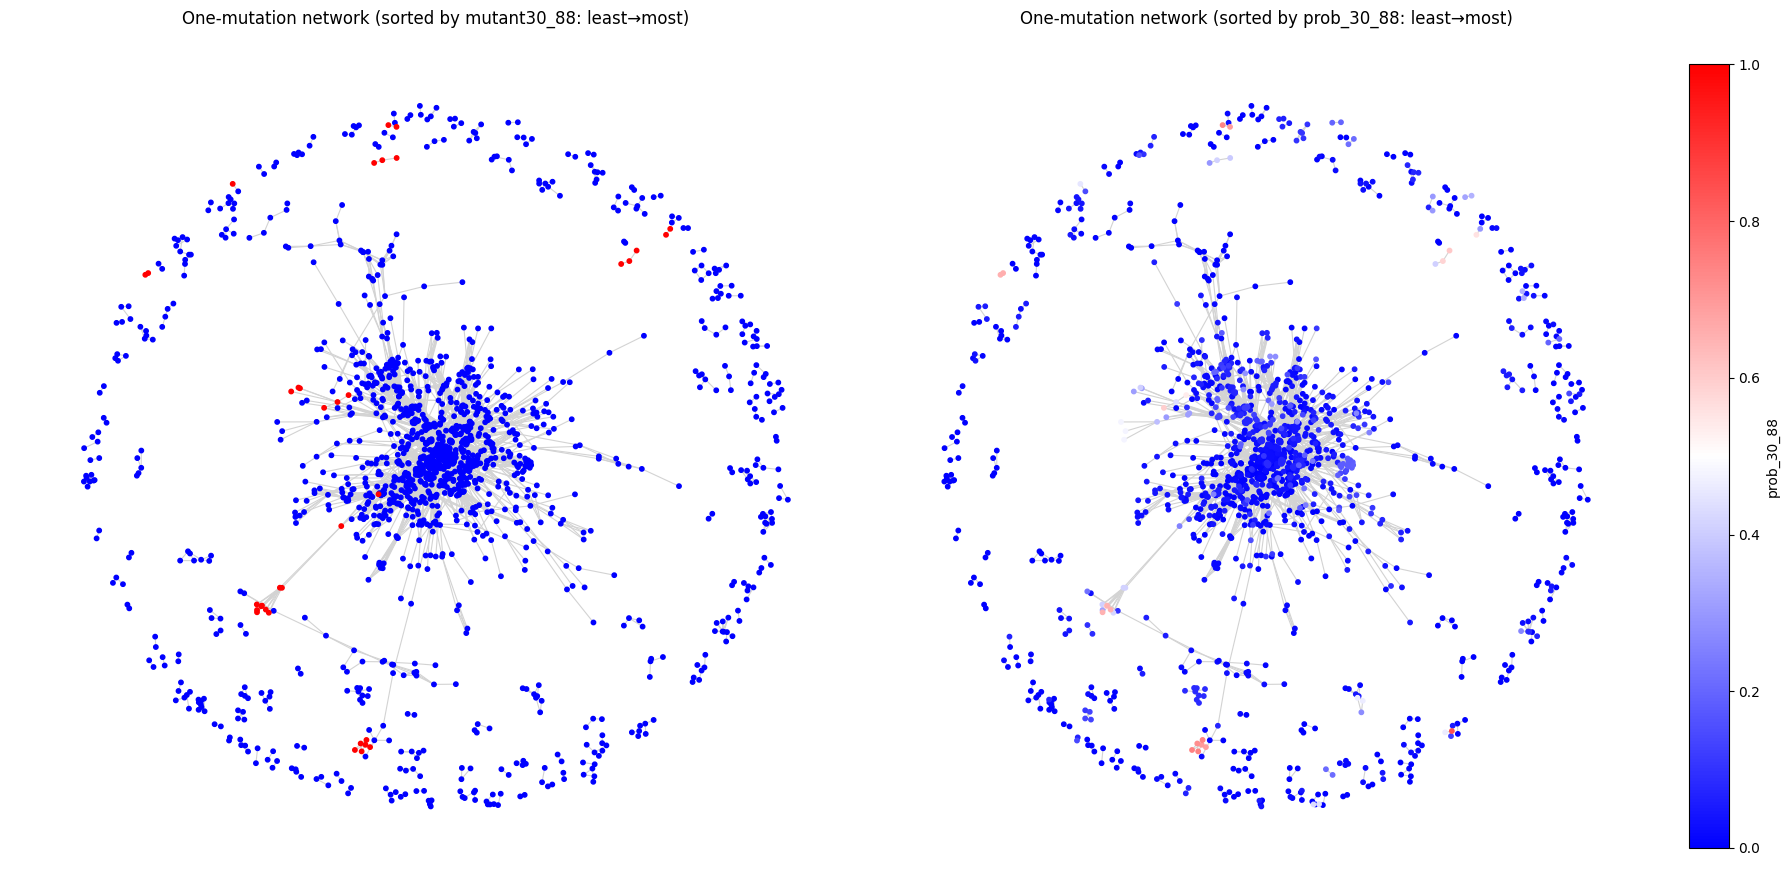

Total nodes: 5710, edges: 18022
Connected (degree>0) nodes plotted: 1700


In [9]:
import networkx as nx
from collections import defaultdict
from itertools import combinations
import matplotlib.pyplot as plt

# Build graph: nodes are sequence indices, edges connect sequences at Hamming distance 1
seqs = PR_all_seq_unreduced
n = len(seqs)
L = len(seqs[0])

G = nx.Graph()
G.add_nodes_from(range(n))

for pos_idx in range(L):
    buckets = defaultdict(list)
    for idx, s in enumerate(seqs):
        key = s[:pos_idx] + s[pos_idx + 1:]
        buckets[key].append(idx)

    for group in buckets.values():
        if len(group) < 2:
            continue
        for i, j in combinations(group, 2):
            if seqs[i][pos_idx] != seqs[j][pos_idx]:
                G.add_edge(i, j)

connected_nodes = [node for node, deg in G.degree() if deg > 0]
Gc = G.subgraph(connected_nodes).copy()

pos = nx.spring_layout(Gc, seed=42)

# Sort orders requested
nodes_first = sorted(Gc.nodes(), key=lambda i: df_results.loc[i, "mutant30_88"])   # least -> most
nodes_second = sorted(Gc.nodes(), key=lambda i: df_results.loc[i, "prob_30_88"])  # least -> most

colors_30_88 = ["red" if df_results.loc[i, "mutant30_88"] == 1 else "blue" for i in nodes_first]
prob_colors_30_88 = [df_results.loc[i, "prob_30_88"] for i in nodes_second]

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# Left: binary mutant color (sorted by mutant30_88)
nx.draw_networkx_edges(Gc, pos, ax=axes[0], edge_color="lightgray", width=0.8)
nx.draw_networkx_nodes(
    Gc, pos, nodelist=nodes_first, ax=axes[0],
    node_color=colors_30_88, node_size=10
)
axes[0].set_title("One-mutation network (sorted by mutant30_88: least→most)")
axes[0].axis("off")

# Right: graded prob_30_88 color (sorted by prob_30_88)
nx.draw_networkx_edges(Gc, pos, ax=axes[1], edge_color="lightgray", width=0.8)
nodes = nx.draw_networkx_nodes(
    Gc, pos, nodelist=nodes_second, ax=axes[1],
    node_color=prob_colors_30_88, cmap=plt.cm.bwr, vmin=0, vmax=1, node_size=10
)
axes[1].set_title("One-mutation network (sorted by prob_30_88: least→most)")
axes[1].axis("off")
plt.colorbar(nodes, ax=axes[1], fraction=0.046, pad=0.04, label="prob_30_88")

plt.tight_layout()
plt.show()

print(f"Total nodes: {G.number_of_nodes()}, edges: {G.number_of_edges()}")
print(f"Connected (degree>0) nodes plotted: {Gc.number_of_nodes()}")


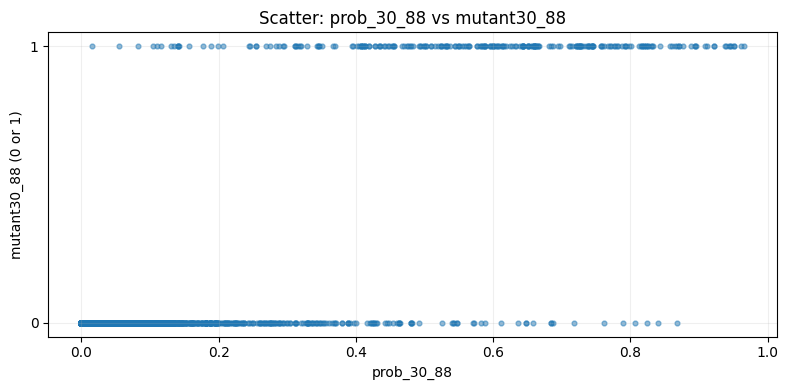

In [10]:
plt.figure(figsize=(8, 4))
plt.scatter(df_results["prob_30_88"], df_results["mutant30_88"], alpha=0.5, s=12)

plt.xlabel("prob_30_88")
plt.ylabel("mutant30_88 (0 or 1)")
plt.yticks([0, 1])
plt.title("Scatter: prob_30_88 vs mutant30_88")
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

Total count (mutant30_88 = 0): 5463
Total count (mutant30_88 = 1): 247


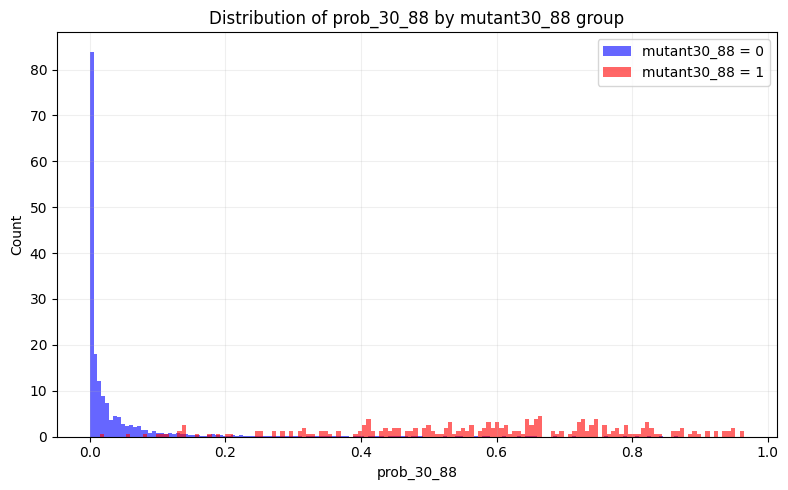

In [11]:
vals_0 = df_results.loc[df_results["mutant30_88"] == 0, "prob_30_88"]
vals_1 = df_results.loc[df_results["mutant30_88"] == 1, "prob_30_88"]
print(f"Total count (mutant30_88 = 0): {len(vals_0)}")
print(f"Total count (mutant30_88 = 1): {len(vals_1)}")
plt.figure(figsize=(8, 5))
plt.hist(vals_0, bins=150, alpha=0.6, density =True, label="mutant30_88 = 0", color="blue")
plt.hist(vals_1, bins=150, alpha=0.6, density =True, label="mutant30_88 = 1", color="red")

plt.xlabel("prob_30_88")
plt.ylabel("Count")
plt.title("Distribution of prob_30_88 by mutant30_88 group")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [12]:
mutations_5601= functions.get_mutations_from_sequence(PR_all_seq[5601], PR_consensus_seq)
mutations_5601_unreduced = []
for mutation in mutations_5601:
    mutations_5601_unreduced.append(functions.reduced_to_unreduced(PR_redux, mutation, PR_all_seq_unreduced, 1))
print(f"Unreduced mutations in sequence at index 5601: {mutations_5601_unreduced}")

Unreduced mutations in sequence at index 5601: ['N30D', 'D35E', 'V36M', 'R45K', 'V62I', 'A63L', 'T71A', 'I77V', 'I89L']
